In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [3]:
#Load Dataset
df = pd.read_csv("data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
import os 
os.getcwd()


'C:\\Users\\barat\\Desktop\\churn-ml-system'

In [5]:
os.path.exists("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

False

In [6]:
# Basic Inspection
print("shape:", df.shape)
df.info()
df.describe()

shape: (7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   s

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors = "coerce")
df["TotalCharges"].dtype

dtype('float64')

In [8]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [9]:
#Target Variable Analysis
df["Churn"].value_counts()
df["Churn"].value_counts(normalize = True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

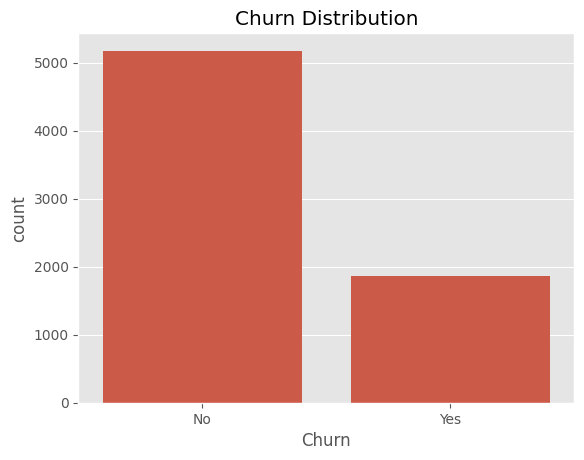

In [10]:
sns.countplot(x = "Churn", data=df)
plt.title("Churn Distribution")
plt.show()

In [11]:
#Separate Feature Types
categorical_cols = df.select_dtypes(include="object").columns
numerical_cols = df.select_dtypes(exclude="object").columns

print("Categorical:", len(categorical_cols))
print("Numerical:", len(numerical_cols))

Categorical: 17
Numerical: 4


C:\Users\barat\AppData\Local\Temp\ipykernel_7476\1600738704.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


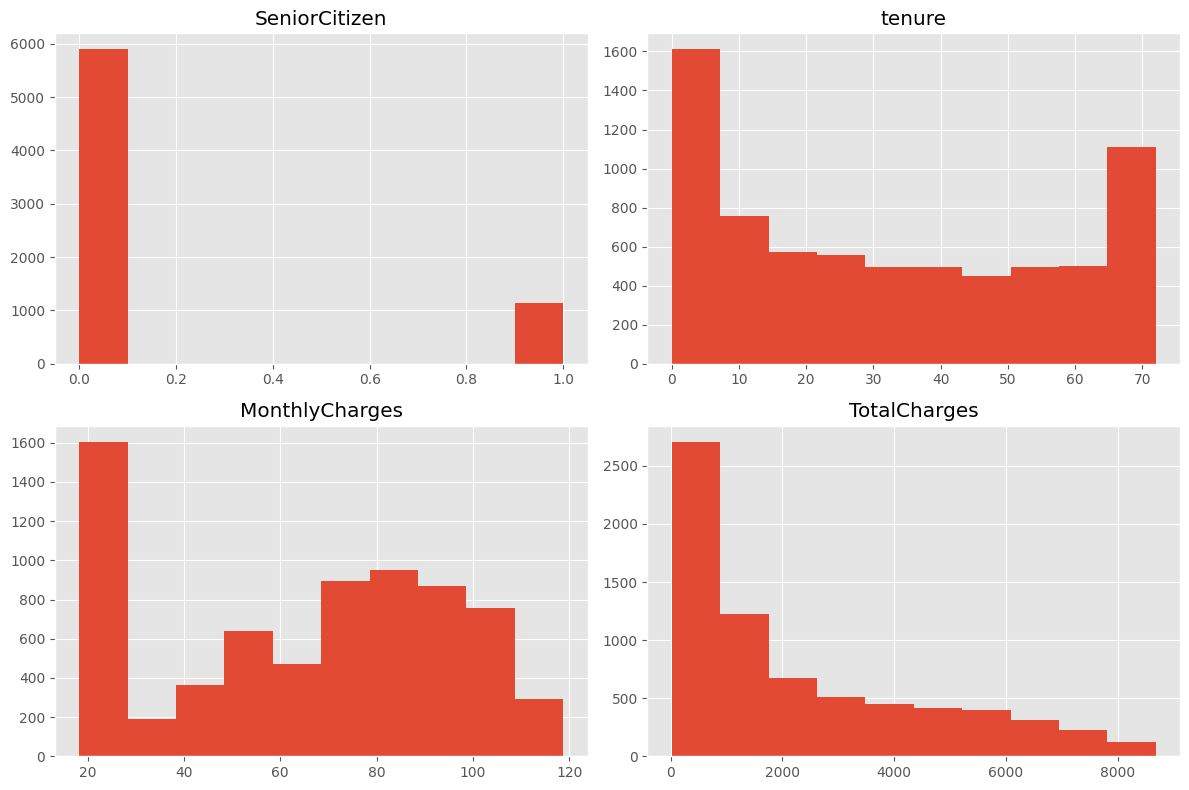

In [12]:
#Quick Numerical Distribution Check
df[numerical_cols].hist(figsize = (12,8))
plt.tight_layout()
plt.show()

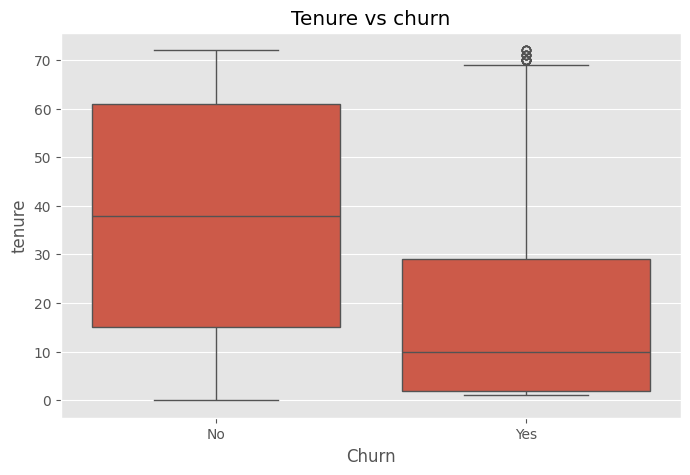

In [13]:
#Deep Behavioral EDA
plt.figure(figsize=(8,5))
sns.boxplot(x = 'Churn', y = 'tenure', data = df)
plt.title("Tenure vs churn")
plt.show()

In [14]:
#Contract vs Churn
pd.crosstab(df['Contract'], df["Churn"], normalize = "index")

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


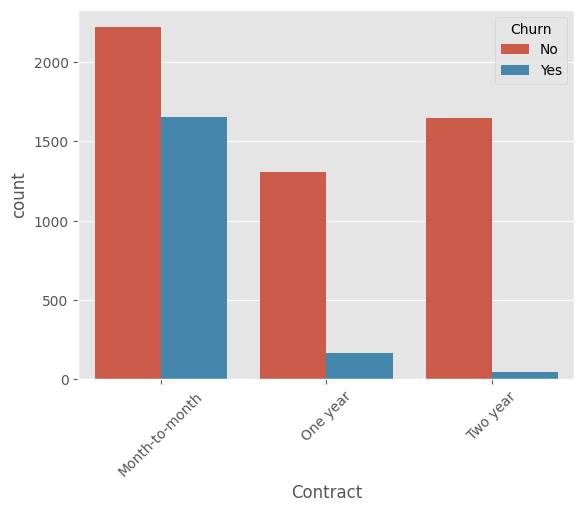

In [15]:
sns.countplot(x = "Contract", hue = "Churn",data = df)
plt.xticks(rotation = 45)
plt.show()

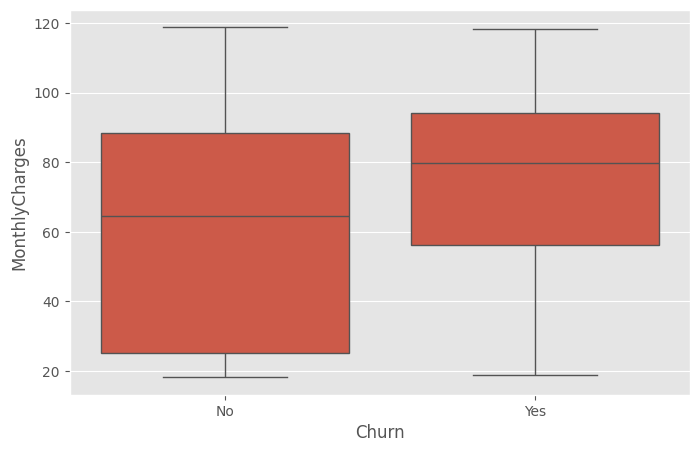

In [16]:
#MonthlyCharges vs Churn
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()

In [17]:
#TechSupport vs Churn
pd.crosstab(df["TechSupport"], df["Churn"], normalize="index")

Churn,No,Yes
TechSupport,,
No,0.583645,0.416355
No internet service,0.925950,0.074050
Yes,0.848337,0.151663


In [18]:
#Deep Churn Behavior Analysis + Leakage Detection
df = df.drop(columns=["customerID"])
df.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [19]:
#Convert Target to Binary
df["Churn"] = df["Churn"].map({"Yes":1,"No":0})

In [20]:
#Deep Feature vs Churn Analysis
#Tenure Buckets (This Is Advanced Thinking)
df["tenure_group"] = pd.cut(df["tenure"],
                            bins=[0,12,24,36,48,60,72],
                            labels=["0-12","12-24","24-48","36-48","48-60","60-72"])
pd.crosstab(df["tenure_group"],df["Churn"], normalize = "index")

Churn,0,1
tenure_group,,
0-12,0.523218,0.476782
12-24,0.712891,0.287109
24-48,0.783654,0.216346
36-48,0.809711,0.190289
48-60,0.855769,0.144231
60-72,0.933902,0.066098


In [21]:
#Contract Type Impact
pd.crosstab(df["Contract"],df["Churn"],normalize = "index")

Churn,0,1
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


In [22]:
#Payment Method
pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index")

Churn,0,1
PaymentMethod,,
Bank transfer (automatic),0.832902,0.167098
Credit card (automatic),0.847569,0.152431
Electronic check,0.547146,0.452854
Mailed check,0.808933,0.191067


In [23]:
#Internet Service + Tech Support Interaction
pd.crosstab([df["InternetService"], df["TechSupport"]], df["Churn"],normalize="index")

Churn                                       0         1
InternetService TechSupport                            
DSL             No                   0.722446  0.277554
                Yes                  0.903226  0.096774
Fiber optic     No                   0.506278  0.493722
                Yes                  0.773672  0.226328
No              No internet service  0.925950  0.074050

In [24]:
#Professional Feature Engineering + Proper Split
#Separate Target & Features
X = df.drop(columns = ["Churn"])
y = df["Churn"]

In [25]:
#Train / Test Split (Stratified)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [26]:
#identify Column Types
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns
print("Categorical:", len(categorical_cols))
print("Numerical:", len(numerical_cols))

Categorical: 15
Numerical: 5


C:\Users\barat\AppData\Local\Temp\ipykernel_7476\2442119527.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns


In [27]:
#Remember:SeniorCitizen should be treated as categorical.
df["SeniorCitizen"].unique() # its show 0,1 but its a categotical seniorcetizen may have numbers but its a label categoricalll so we need to change catgorical

array([0, 1])

In [28]:
#SeniorCitizen should be treated as categorical.
X_train["SeniorCitizen"] = X_train["SeniorCitizen"].astype("object")
X_test["SeniorCitizen"] = X_test["SeniorCitizen"].astype("object")

In [29]:
#Build Preprocessing Pipeline
#ColumnTransformer

#Pipeline

#OneHotEncoder

#StandardScaler

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [31]:
#Build Baseline Model (Logistic Regression)
from sklearn.linear_model import LogisticRegression

model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

In [32]:
model.fit(X_train, y_train)

ValueError: could not convert string to float: '24-48'

In [ ]:
# The model is failing because:

#LogisticRegression does not accept missing values (NaN).

# Even though a preprocessing pipeline was created, the error indicates that NaN values are still present in the feature matrix (X) when the model tries to fit.

In [33]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

NotFittedError: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [34]:
# we just got the error becoz of missing nan values so here is how to solve 

# There are still missing values in your dataset.

 #Most likely:
### TotalCharges after pd.to_numeric(errors="coerce") created NaNs.

# And here’s the key:

# Even if you dropped 11 rows earlier, after re-splitting or recreating df, those NaNs might still exist.

In [35]:
from sklearn.metrics import classification_report,roc_auc_score,accuracy_score

#predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

# aCCURACY
print("AAccuracy",accuracy_score(y_test,y_pred))

# Full report
print("\n classification reports \n")

print(classification_report(y_test, y_pred))

# ROC-AUC
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

NotFittedError: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [36]:
# to solve this we have to use simpleimputer here is my solution if u forgot this project just reminder for u to understand this steps work to solve leakge

In [37]:
#Ensure Correct Data Types
df["SeniorCitizen"] = df["SeniorCitizen"].astype("object")
df["tenure_group"] = df["tenure_group"].astype("object")

In [38]:
#Recreate X and y
X = df.drop(columns=["Churn"])
y = df["Churn"]

In [39]:
#Split (Stratified Again)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [40]:
#Recalculate Column Groups (IMPORTANT)
categorical_cols = X_train.select_dtypes(include="object").columns
numerical_cols = X_train.select_dtypes(exclude="object").columns

C:\Users\barat\AppData\Local\Temp\ipykernel_7476\3672855129.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include="object").columns


In [41]:
print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group'],
      dtype='str')
Numerical: Index(['tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')


In [42]:
# add SimpleImputer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [43]:
#Rebuild Model Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

In [44]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [45]:
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Full report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ROC-AUC
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.8034066713981547

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409

ROC-AUC: 0.8431088377379938


In [46]:
import numpy as np
from sklearn.metrics import classification_report

threshold = 0.3
y_pred_custom = (y_prob >= threshold).astype(int)

print("Threshold:", threshold)
print(classification_report(y_test, y_pred_custom))

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.89      0.75      0.82      1035
           1       0.52      0.75      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.75      0.76      1409



In [47]:
#Non-Linear Model: Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ('preprocessing',preprocessor),
    ('classifier',RandomForestClassifier(n_estimators = 200,max_depth=None,random_state=42))
])
rf_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [48]:
#Evaluate
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.7821149751596878

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409

ROC-AUC: 0.8219703428143326


In [49]:
threshold = 0.3
y_pred_rf_custom = (y_prob_rf >= threshold).astype(int)

print(classification_report(y_test, y_pred_rf_custom))

              precision    recall  f1-score   support

           0       0.88      0.75      0.81      1035
           1       0.51      0.73      0.60       374

    accuracy                           0.74      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.79      0.74      0.76      1409



In [50]:
#Why This Matters

#If Random Forest:

#Improves recall significantly

#Improves ROC-AUC

#Then churn problem has non-linear structure.

#If it doesn’t improve much:

#Logistic is already strong

#Problem may be mostly linear

#Either result is valuable.
#


In [51]:
#Gradient Boosting (HistGradientBoostingClassifier)
#Train Gradient Boosting
from sklearn.ensemble import HistGradientBoostingClassifier

gb_model = Pipeline([
    ('preprocessor',preprocessor),
    ('classifier',HistGradientBoostingClassifier(learning_rate = 0.1,max_iter=200,random_state=42))
])

gb_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [52]:
#Evaluate
from sklearn.metrics import classification_report,roc_auc_score,accuracy_score

y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:,1]

print('Accuracy:',accuracy_score(y_test,y_pred_gb))
print("\nClassification Reports:\n")
print(classification_report(y_test,y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_gb))


Accuracy: 0.7821149751596878

Classification Reports:

              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1035
           1       0.61      0.52      0.56       374

    accuracy                           0.78      1409
   macro avg       0.72      0.70      0.71      1409
weighted avg       0.77      0.78      0.78      1409

ROC-AUC: 0.8274496887028857


In [53]:
#Threshold 0.3 
threshold = 0.3
y_pred_gb_custom = (y_pred_gb >= threshold).astype(int)
print("Thresgold:",threshold)
print(classification_report(y_test,y_pred_gb_custom))

Thresgold: 0.3
              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1035
           1       0.61      0.52      0.56       374

    accuracy                           0.78      1409
   macro avg       0.72      0.70      0.71      1409
weighted avg       0.77      0.78      0.78      1409



In [54]:
# Important Observation

# Gradient Boosting did not outperform Logistic.
# This dataset is largely linearly separable.3# Logistic Regression is already capturing most of the signal.
# Boosting did not add much value.


In [55]:
# Instead of chasing more models…

#We improve the current best model.

#Two smart moves:

#1️ Add class_weight="balanced" to Logistic
# Tune regularization (C parameter)

#That’s professional refinement.

In [56]:
#Upgrade Logistic Properly
from sklearn.linear_model import LogisticRegression

model_balanced = Pipeline([
    ('preproccesor',preprocessor),
    ('classifier:',LogisticRegression(max_iter = 1000, class_weight = "balanced",C = 1.0))
])

model_balanced.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preproccesor', ...), ('classifier:', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [57]:
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

y_pred_bal = model_balanced.predict(X_test)
y_prob_bal = model_balanced.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_bal))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_bal))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_bal))

Accuracy: 0.7409510290986515

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.8428685835335452


In [58]:
#Tune the C parameter (regularization strength).
#Reminder:

#Small C → stronger regularization → simpler model

#Large C → weaker regularization → more complex model

In [59]:
#Grid Search for C
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    'classifier__c':[0.01,0.1,1,5,10]
}

model_tuned = Pipeline([
    ('preprocessing',preprocessor),
    ('classifier',LogisticRegression(max_iter = 1000,class_weight = "balanced"))
])

grid_search = GridSearchCV(
    model_tuned,
    param_grid,
    cv=5,
    scoring = "roc_auc",
    n_jobs = 2
)

grid_search.fit(X_train,y_train)
print("C:", grid_search.best_params_)
print("Best cv roc_auc:",grid_search.best_score_)

ValueError: Invalid parameter 'c' for estimator LogisticRegression(class_weight='balanced', max_iter=1000). Valid parameters are: ['C', 'class_weight', 'dual', 'fit_intercept', 'intercept_scaling', 'l1_ratio', 'max_iter', 'n_jobs', 'penalty', 'random_state', 'solver', 'tol', 'verbose', 'warm_start'].

In [ ]:
# one small mistake cost your code check this lol i just typed small c and the code doesnt give any output give sme invalud paramter param_grid = {
   # 'classifier__c':[0.01,0.1,1,5,10]
#}

In [63]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    "classifier__C": [0.01, 0.1, 1, 5, 10]
}

model_tuned = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

grid_search = GridSearchCV(
    model_tuned,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=2
)

grid_search.fit(X_train, y_train)

print("Best C:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)

Best C: {'classifier__C': 10}
Best CV ROC-AUC: 0.8487387671093096


In [64]:
#Evaluate Best Model on Test Set
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_best))

Accuracy: 0.7402413058907026

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.8418248986023922


In [65]:
#Extract Feature Names After One-Hot Encoding
## Get feature names after preprocessing

In [66]:
# Get feature names after preprocessing
ohe = best_model.named_steps["preprocessing"].named_transformers_["cat"].named_steps["encoder"]

encoded_cat_features = ohe.get_feature_names_out(categorical_cols)

all_features = list(numerical_cols) + list(encoded_cat_features)

In [67]:
#Extract Coefficients
coefficients = best_model.named_steps["classifier"].coef_[0]

feature_importance = pd.DataFrame({
    "all_features": all_features,
    "coefficient":coefficients
})

feature_importance["abs_coef"] = np.abs(feature_importance["coefficient"])

feature_importance = feature_importance.sort_values("abs_coef",ascending = False)

feature_importance.head(15)      # this steps are lit confusing me have to use chatgpt and learn this and do similar problem remeber it

,all_features,coefficient,abs_coef
1,MonthlyCharges,-1.990840,1.990840
0,tenure,-1.953118,1.953118
51,tenure_group_60-72,1.608584,1.608584
17,InternetService_Fiber optic,1.423896,1.423896
46,tenure_group_0-12,-1.274944,1.274944
47,tenure_group_12-24,-1.159080,1.159080
16,InternetService_DSL,-1.114056,1.114056
50,tenure_group_48-60,0.973677,0.973677
39,Contract_Two year,-0.868301,0.868301
48,tenure_group_24-48,-0.737348,0.737348


In [68]:
# its seems it not working ebcoz of array must be same length lets fix this ##

In [69]:
#Correct Way to Get Feature Names From ColumnTransformer
feature_names = best_model.named_steps["preprocessing"].get_feature_names_out()

# check lengthhhh

print("no of feautes:", len(feature_names))
print("no of coeffiencts:", len(best_model.named_steps["classifier"].coef_[0]))

no of feautes: 52
no of coeffiencts: 52


In [70]:
##Extract Coefficients
coefficients = best_model.named_steps["classifier"].coef_[0]

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

feature_importance["abs_coef"] = np.abs(feature_importance["coefficient"])

feature_importance = feature_importance.sort_values("abs_coef", ascending=False)

feature_importance.head(15)

,feature,coefficient,abs_coef
1,num__MonthlyCharges,-1.990840,1.990840
0,num__tenure,-1.953118,1.953118
51,cat__tenure_group_60-72,1.608584,1.608584
17,cat__InternetService_Fiber optic,1.423896,1.423896
46,cat__tenure_group_0-12,-1.274944,1.274944
47,cat__tenure_group_12-24,-1.159080,1.159080
16,cat__InternetService_DSL,-1.114056,1.114056
50,cat__tenure_group_48-60,0.973677,0.973677
39,cat__Contract_Two year,-0.868301,0.868301
48,cat__tenure_group_24-48,-0.737348,0.737348


In [71]:

#tenure + tenure_group together are causing coefficient distortion.

#So we remove the engineered bucket and retrain cleanly.
#


In [72]:
#Remove tenure_group
df = df.drop(columns = ["tenure_group"])


In [73]:
#Rebuild X and y
X = df.drop(columns=["Churn"])
y = df["Churn"]

In [74]:
#TRAIN TEST

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [75]:
#Re-identify Column Types
categorical_cols = X_train.select_dtypes(include="object").columns
numerical_cols = X_train.select_dtypes(exclude="object").columns
print(categorical_cols)
print(numerical_cols)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='str')
Index(['tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')


C:\Users\barat\AppData\Local\Temp\ipykernel_7476\864011472.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include="object").columns


In [76]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])


In [77]:
from sklearn.linear_model import LogisticRegression

model_clean = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        C=1.0
    ))
])

model_clean.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [78]:
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

y_pred_clean = model_clean.predict(X_test)
y_prob_clean = model_clean.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_clean))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_clean))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_clean))

Accuracy: 0.7374024130589071

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.8414063912785139


In [79]:
feature_names = model_clean.named_steps["preprocessing"].get_feature_names_out()
coefficients = model_clean.named_steps["classifier"].coef_[0]

import pandas as pd
import numpy as np

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

feature_importance["abs_coef"] = np.abs(feature_importance["coefficient"])
feature_importance = feature_importance.sort_values("abs_coef", ascending=False)

feature_importance.head(15)

,feature,coefficient,abs_coef
0,num__tenure,-1.137335,1.137335
39,cat__Contract_Two year,-0.778770,0.778770
17,cat__InternetService_Fiber optic,0.716951,0.716951
1,num__MonthlyCharges,-0.677196,0.677196
37,cat__Contract_Month-to-month,0.668241,0.668241
16,cat__InternetService_DSL,-0.619467,0.619467
2,num__TotalCharges,0.472171,0.472171
36,cat__StreamingMovies_Yes,0.283077,0.283077
26,cat__DeviceProtection_No internet service,-0.270423,0.270423
20,cat__OnlineSecurity_No internet service,-0.270423,0.270423


In [62]:
#BUSINESS DECISION LAYER
#Right now your best model:

#Balanced Logistic

#Recall ≈ 0.79–0.80

#ROC-AUC ≈ 0.84

#Precision ≈ 0.51

#So the question is not:

“#Is the model good?”

#The question is:

#👉 How do we USE it?

In [80]:
#tep 1 — Choose Deployment Threshold
#Right now, default threshold = 0.5

#That gave:

#Recall ≈ 0.79–0.80

#We also tried 0.3 earlier and saw recall increase in some models.

#Now we decide intentionally.

#🧠 Business Framing

#Assume:

#Cost to contact a customer = small

#Cost of losing a customer = large

#Then missing churners is expensive.

#So we want:

#👉 High recall (catch as many churners as possible)

#Precision can be moderate.

#Your balanced logistic already gives:

#Recall ~80%
#
#Precision ~51%

#That means:

#When we predict churn:
#About half truly churn.

#That’s acceptable in retention campaigns.

#💼 Business Recommendation

#We would say:

#Deploy model with class_weight="balanced" and default threshold 0.5, targeting top-risk customers weekly.

#Or we could:
#
#👉 Rank customers by churn probability
#👉 Contact top 20–30% highest risk

#That’s often better than fixed threshold.

In [82]:
#Step 2 — Rank Customers by Risk

# create dataframe with probabilities
risk_df = X_test.copy()
risk_df["true_churn"] = y_test.values
risk_df["churn_probability"] = y_prob_clean

risk_df = risk_df.sort_values("churn_probability",ascending = False)
risk_df.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,true_churn,churn_probability
3380,Male,1,Yes,No,1,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.10,95.10,1,0.937999
6866,Male,0,No,No,1,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.45,95.45,1,0.926767
2631,Male,1,Yes,No,7,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.25,665.45,1,0.926054
6365,Male,1,Yes,No,7,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,101.95,700.85,1,0.922318
4585,Female,1,No,No,1,Yes,Yes,Fiber optic,No,No,...,No,No,Yes,Month-to-month,Yes,Electronic check,85.05,85.05,1,0.920408
3346,Female,1,No,No,2,Yes,Yes,Fiber optic,No,No,...,No,No,Yes,Month-to-month,Yes,Electronic check,84.05,186.05,0,0.920196
6894,Male,1,Yes,No,3,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,105.90,334.65,1,0.920033
2797,Male,0,No,No,3,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.95,329.95,1,0.919405
3727,Female,0,No,No,3,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,96.60,291.90,1,0.918955
4039,Male,0,No,No,7,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.10,701.30,0,0.918056


In [83]:
#If the company can only contact 25% of customers,
#what churn probability cutoff would you choose?

top_25percent = int(len(risk_df) * 0.25)
risk_df.iloc[:top_25percent]["true_churn"].mean()

np.float64(0.625)

In [84]:
import joblib

joblib.dump(model_clean, "churn_model.pkl")

['churn_model.pkl']